In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Task 1

In [2]:
img = cv2.imread("fingerprint.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(img, (100, 100), 20, 255, thickness=2)
    cv2.circle(img, (100, 100), 40, 255, thickness=2)

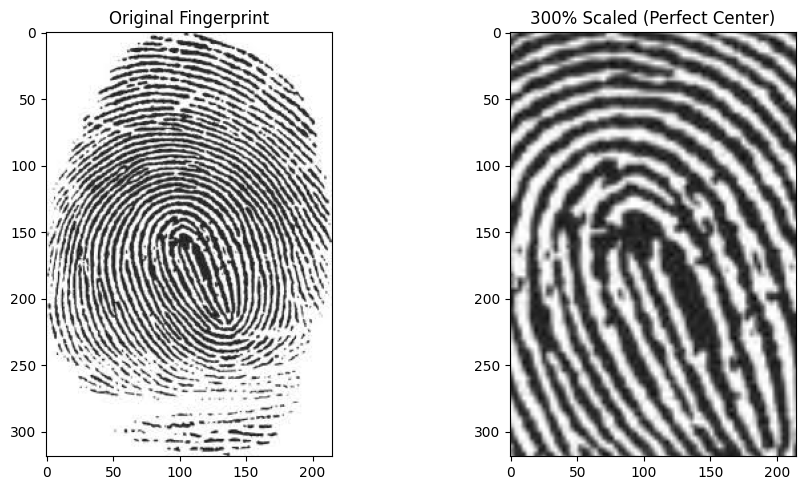

In [3]:
height, width = img.shape

# 2. Get center coordinates
center = (width / 2.0, height / 2.0)

# 3. Automatically generate the correct inverse matrix
# Parameters: (center_xy_tuple, angle_of_rotation, scale_factor)
M = cv2.getRotationMatrix2D(center, angle=0, scale=3.0)

# 4. Apply the transformation with a white background fallback
# We set borderValue=255 so any empty edges match the white paper background
scaled_img = cv2.warpAffine(img, M, (width, height), borderValue=255)

# 5. Display the corrected results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original Fingerprint")
axes[0].axis("on")

axes[1].imshow(scaled_img, cmap="gray")
axes[1].set_title("300% Scaled (Perfect Center)")
axes[1].axis("on")

plt.tight_layout()
plt.show()


## Task 2

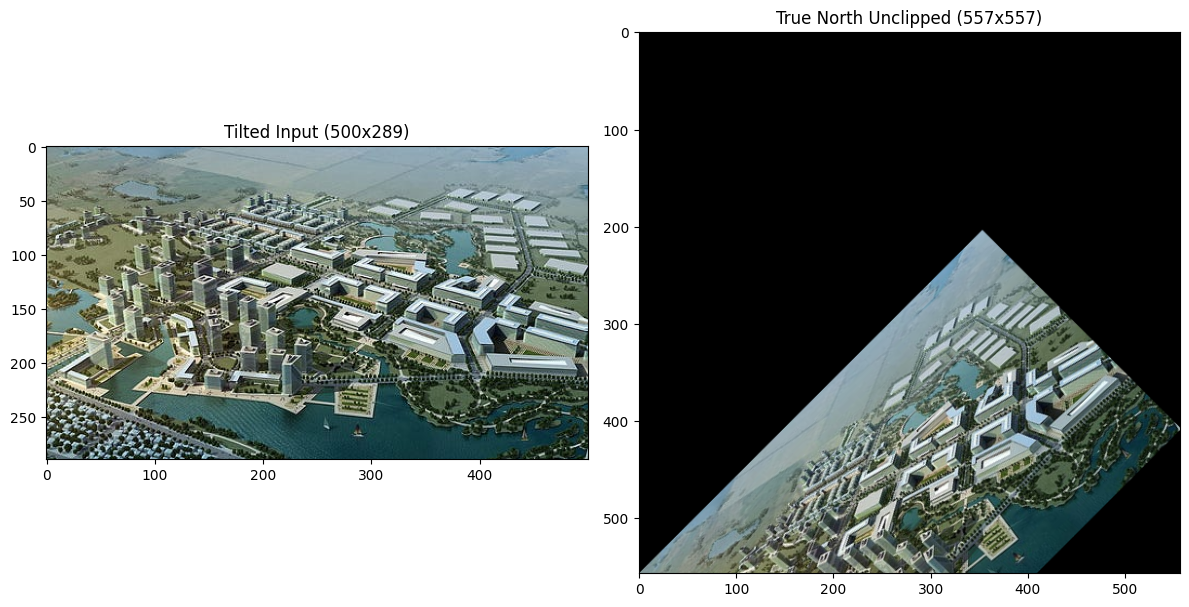

In [4]:
city_img = cv2.imread("satellite_city.jpg")

h_orig, w_orig, channels = city_img.shape
cx_orig = w_orig / 2.0
cy_orig = h_orig / 2.0

angle_deg = -45.0
angle_rad = np.radians(angle_deg)

cos_t = np.cos(angle_rad)
sin_t = np.sin(angle_rad)

w_new = int(w_orig * abs(cos_t) + h_orig * abs(sin_t))
h_new = int(w_orig * abs(sin_t) + h_orig * abs(cos_t))

cx_new = w_new / 2.0
cy_new = h_new / 2.0

tx = cx_new - (cos_t * cx_orig - sin_t * cy_orig)
ty = cy_new - (sin_t * cx_orig - cos_t * cy_orig)

M = np.array([[cos_t, -sin_t, tx], [sin_t, cos_t, ty]], dtype=np.float32)

rotated_img = cv2.warpAffine(city_img, M, (w_new, h_new))

img_rgb = cv2.cvtColor(city_img, cv2.COLOR_BGR2RGB)
rotated_rgb = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_rgb)
axes[0].set_title(f"Tilted Input ({w_orig}x{h_orig})")
axes[0].axis("on")

axes[1].imshow(rotated_rgb)
axes[1].set_title(f"True North Unclipped ({w_new}x{h_new})")
axes[1].axis("on")

plt.tight_layout()
plt.show()

## Task 3

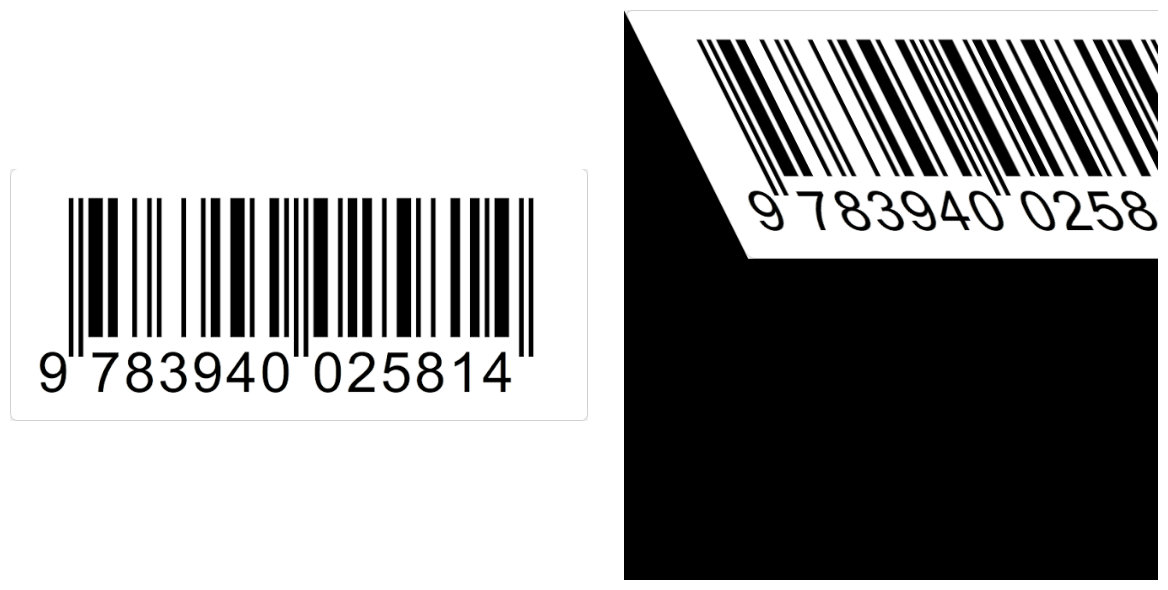

In [5]:
barcode = cv2.imread("barcode.png")

width, height = barcode.shape[:2]

kx = 0.5

M = np.float32([
    [1, kx, 0],
    [0, 1, 0]
])

new_width = int(width + abs(kx) * height)

sheared = cv2.warpAffine(barcode, M, (new_width, height))

barcode_rgb = cv2.cvtColor(barcode, cv2.COLOR_BGR2RGB)
sheared_barcode_rgb = cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(barcode_rgb)
axes[0].axis("off")

axes[1].imshow(sheared_barcode_rgb)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Task 4

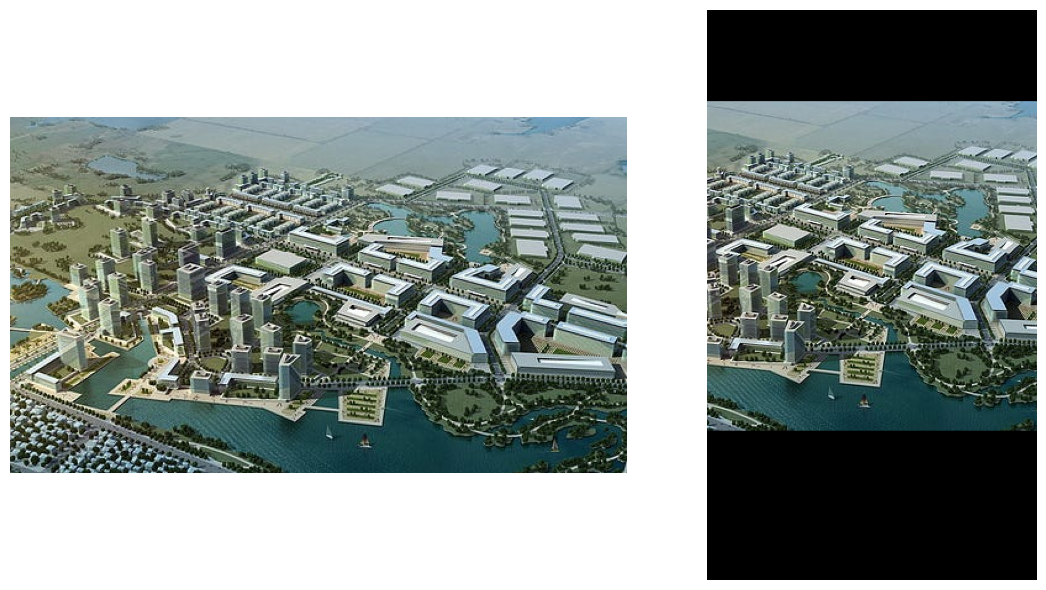

In [6]:
tx = -150
ty = 80

M = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

width, height = city_img.shape[:2]

translated = cv2.warpAffine(city_img, M, (width, height))

city_rgb = cv2.cvtColor(city_img, cv2.COLOR_BGR2RGB)
translated_city_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(city_rgb)
axes[0].axis("off")

axes[1].imshow(translated_city_rgb)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Task 5

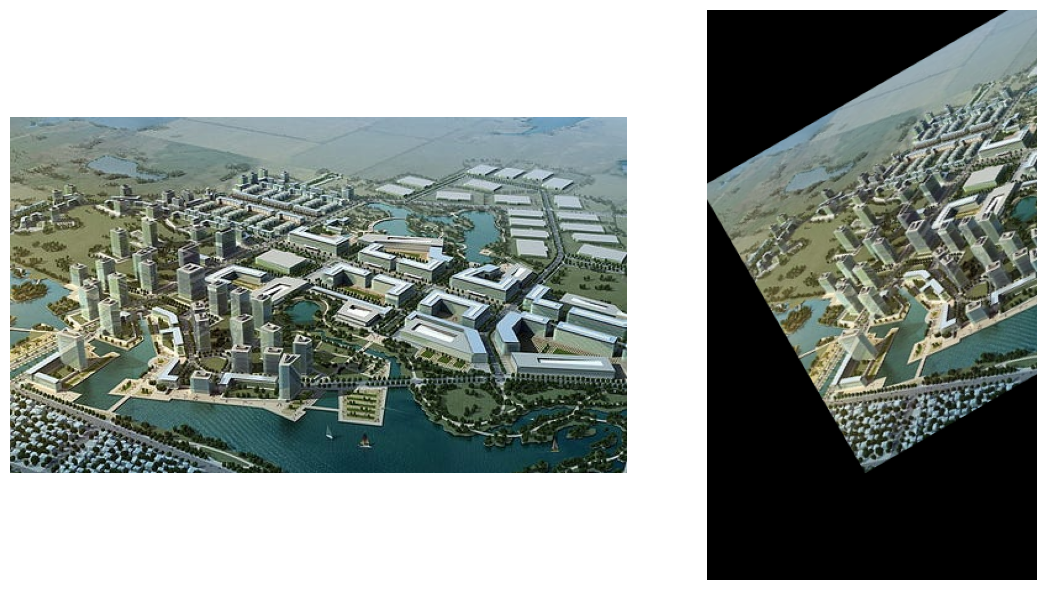

In [7]:
width, height = city_img.shape[:2]

center = (width // 2, height // 2)
angle = 30
scale = 1.0

M = cv2.getRotationMatrix2D(center, angle, scale)

M[0, 2] += 100
M[1, 2] += 50

rigid = cv2.warpAffine(city_img, M, (width, height))

city_rgb = cv2.cvtColor(city_img, cv2.COLOR_BGR2RGB)
rigid_city_rgb = cv2.cvtColor(rigid, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(city_rgb)
axes[0].axis("off")

axes[1].imshow(rigid_city_rgb)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Task 6

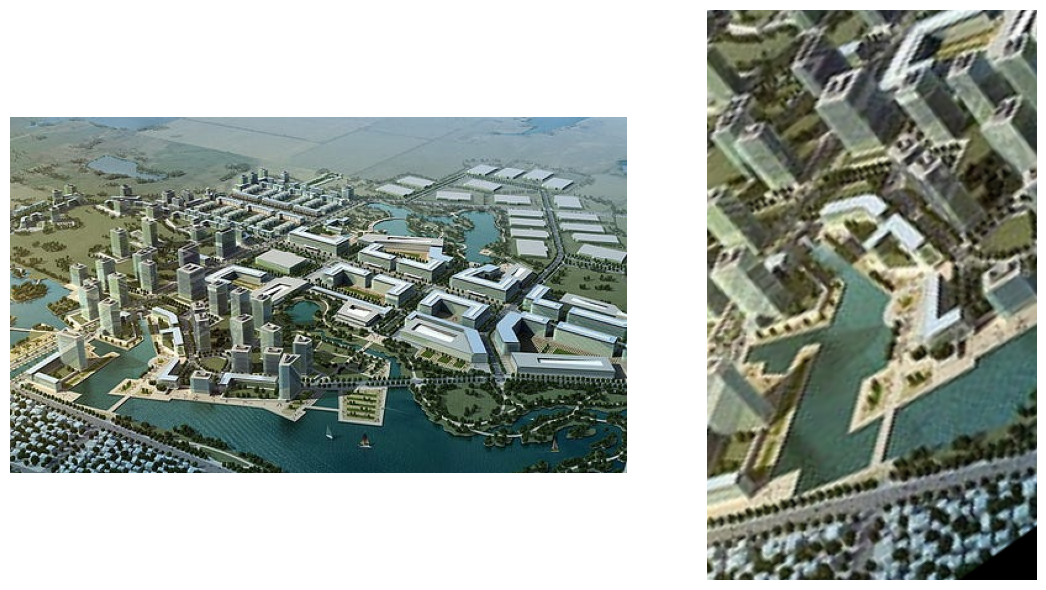

In [8]:
scale = 2.5
angle_deg = 35.0
tx = 150.0
ty = 80.0

width, height = city_img.shape[:2]

center = (width // 2, height // 2)

M = cv2.getRotationMatrix2D(center, angle_deg, scale)

M[0, 2] += tx
M[1, 2] += ty

similarity_transform = cv2.warpAffine(city_img, M, (width, height))

city_rgb = cv2.cvtColor(city_img, cv2.COLOR_BGR2RGB)
similarity_transform_city_rgb = cv2.cvtColor(similarity_transform, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(city_rgb)
axes[0].axis("off")

axes[1].imshow(similarity_transform_city_rgb)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Task 7

Calculated 2x3 Affine Matrix:
[[  1.26666667   0.2        -63.33333333]
 [ -0.13333333   1.          56.66666667]]


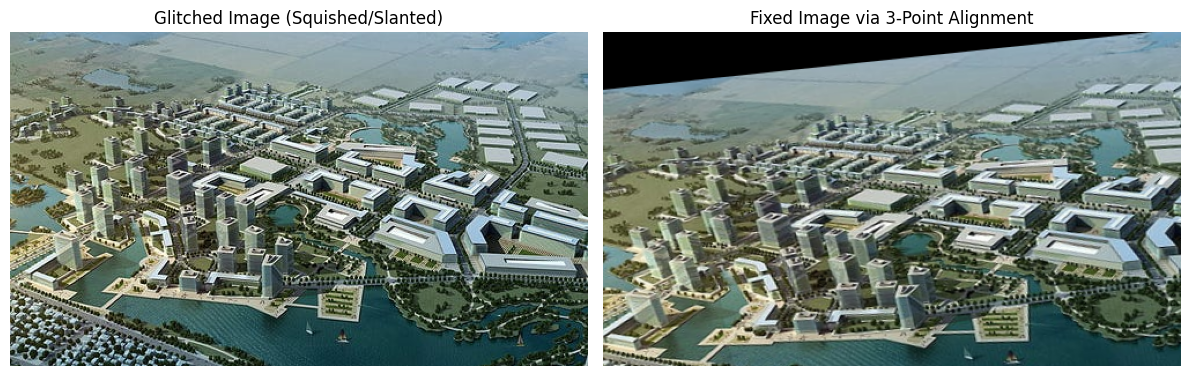

In [9]:
src_points = np.float32([[50, 50], [200, 50], [50, 200]])  # Starting glitched points
dst_points = np.float32(
    [[10, 100], [200, 80], [40, 250]]
)  # Ending target points

# 3. SOLVE THE SYSTEM: This automatically calculates the 2x3 Affine Matrix
M = cv2.getAffineTransform(src_points, dst_points)

print("Calculated 2x3 Affine Matrix:")
print(M)

# 4. Fix the image by applying the solved matrix
height, width = city_img.shape[:2]
fixed_img = cv2.warpAffine(city_img, M, (width, height))

# 5. Display the side-by-side results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(city_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Glitched Image (Squished/Slanted)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(fixed_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Fixed Image via 3-Point Alignment")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Task 8

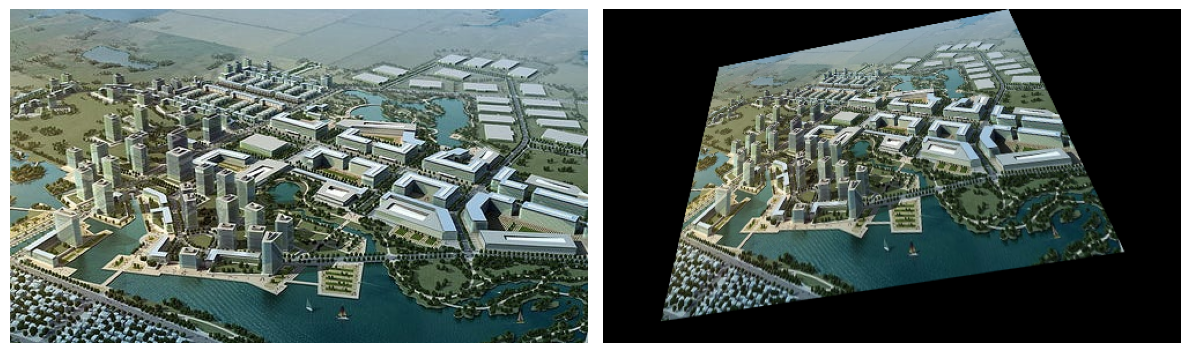

In [10]:
height, width = city_img.shape[:2]

src_points = np.float32([
    [0, 0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0, height - 1]
])

dst_points = np.float32([
    [100, 50],
    [width - 150, 0],
    [width - 50, height - 80],
    [50, height - 20]
])

M = cv2.getPerspectiveTransform(src_points, dst_points)

perspective = cv2.warpPerspective(city_img, M, (width, height))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(city_img, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB))
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Task 9

In [ ]:
# 1. Load the two camera views of the stadium
img1 = cv2.imread("camera_left.png")   # The anchor/base image space
img2 = cv2.imread("camera_right.png")  # The image that will be warped

# 2. Define your 4 matching point coordinates in the overlapping zone
# Format: np.float32([[x1, y1], [x2, y2], [x3, y3], [x4, y4]])
# (Replace these placeholders with your exact point measurements!)
pts_img1 = np.float32([[400, 100], [500, 100], [400, 400], [500, 400]])
pts_img2 = np.float32([[50, 120], , [62, 420],  [160, 405]])

# 3. CALCULATE THE HOMOGRAPHY: Solves the projective matrix system
# cv2.findHomography returns the 3x3 matrix H and a mask array
H, mask = cv2.findHomography(pts_img2, pts_img1, cv2.RANSAC)

print("Calculated 3x3 Homography Matrix:")
print(H)

# 4. WARP PERSPECTIVE: Warp the second image into the perspective of the first
# We allocate an expanded canvas width so the warped image has room to append on the right
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
canvas_width = w1 + w2
canvas_height = max(h1, h2)

panorama = cv2.warpPerspective(img2, H, (canvas_width, canvas_height))

# 5. STITCH: Overlay the anchor image (img1) onto the left side of the panorama canvas
panorama[0:h1, 0:w1] = img1

# 6. Display the final stitched stadium panorama
plt.figure(figsize=(15, 7))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Stitched Stadium Panorama View", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()
